In [33]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import re
import datetime
from itertools import combinations

import numpy as np
import pandas as pd
import pytz
import statsmodels.api as sm

import plotly.io as pio
pio.renderers.default = "vscode"

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
plt.style.use('ggplot')
pylab.rcParams.update({
    'legend.fontsize': 'medium',
    'figure.figsize': (18, 6),
    'axes.labelsize': 'medium',
    'axes.titlesize': 'medium',
    'xtick.labelsize': 'medium',
    'ytick.labelsize': 'medium',
})

import sys
sys.path.append("../../../")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [34]:
NYC_tz = pytz.timezone("America/New_York")

SCREENER_CONFIG = {
    # --- Curve & Tenors ---
    "curve": "USD-SOFR-1D",
    "tenors": ["1y", "2y", "3y", "4y", "5y", "6y", "7y", "8y", "9y", "10y", "12y", "15y", "20y", "25y", "30y"],
    "fwd": "0d",  # forward start ("0d" = spot)

    # --- Data Source ---
    "source": "ERIS_EOD_LIVE-RL_BASIC",

    # --- Timeframe ---
    "lookback_days": 721,
    "end_date": NYC_tz.localize(datetime.datetime(2026, 5, 22, 17, 0)),  # None = now

    # --- Regression ---
    "regression_model": "OLS",  # OLS | TLS

    # --- Rolling Windows ---
    "zscore_windows": [63, 126, 252],  # rolling z-score lookbacks (days)
    "realized_vol_window": 63,  # window for annualized normal vol

    # --- Carry & Roll ---
    "carry_roll_horizon": "3M",  # horizon passed to backend via value_kwargs
    "carry_roll_annual_factor": 4,  # annualize: 3M → ×4, 1M → ×12, 6M → ×2

    # --- Display ---
    "top_n": 25,
    "sort_by": "dir_risk_adj",  # column to sort summary by (absolute value)
}

In [36]:
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from TB.IRSwapsTB import IRSwapsTB
from Query.Unified.UnifiedQuery import UnifiedQuery
from Query.Unified.registry import UnifiedStructure, UnifiedValue
from TB.TimeseriesBuilder import TimeseriesBuilder
from RVUtils.regression import make_linear_regression_builder
from RVUtils.plt_timeseries import make_secondary_axis_plot

cfg = SCREENER_CONFIG
irswaps_mdp = IRSwapsMDP(source=cfg["source"])
irswaps_tb = IRSwapsTB(irswaps_mdp, show_tqdm=True)
tb = TimeseriesBuilder()

end = cfg["end_date"] or NYC_tz.localize(datetime.datetime.now())
start = end - datetime.timedelta(days=cfg["lookback_days"])
fwd = cfg["fwd"]

rate_queries = []
for t in cfg["tenors"]:
    tenor = t if (fwd == "0d" or fwd is None) else f"{fwd}{t}"
    rate_queries.append(UnifiedQuery(curve=cfg["curve"], tenor=tenor, value=UnifiedValue.IRS_RATE))

df_rates = tb.get_timeseries(start=start, end=end, queries=rate_queries, n_jobs=24, routers={"IRS": irswaps_tb})

cr_queries = []
for t in cfg["tenors"]:
    tenor = t if (fwd == "0d" or fwd is None) else f"{fwd}{t}"
    cr_queries.append(
        UnifiedQuery(
            curve=cfg["curve"],
            tenor=tenor,
            value=UnifiedValue.IRS_CARRY_AND_ROLL_BPS_RUNNING,
            value_kwargs={"horizon": cfg["carry_roll_horizon"]},
        )
    )

df_cr = tb.get_timeseries(start=start, end=end, queries=cr_queries, n_jobs=24, routers={"IRS": irswaps_tb})

display(df_rates)
display(df_cr)

,USD-SOFR-1D 10y OUTRIGHT RATE,USD-SOFR-1D 12y OUTRIGHT RATE,USD-SOFR-1D 15y OUTRIGHT RATE,USD-SOFR-1D 1y OUTRIGHT RATE,USD-SOFR-1D 20y OUTRIGHT RATE,USD-SOFR-1D 25y OUTRIGHT RATE,USD-SOFR-1D 2y OUTRIGHT RATE,USD-SOFR-1D 30y OUTRIGHT RATE,USD-SOFR-1D 3y OUTRIGHT RATE,USD-SOFR-1D 4y OUTRIGHT RATE,USD-SOFR-1D 5y OUTRIGHT RATE,USD-SOFR-1D 6y OUTRIGHT RATE,USD-SOFR-1D 7y OUTRIGHT RATE,USD-SOFR-1D 8y OUTRIGHT RATE,USD-SOFR-1D 9y OUTRIGHT RATE
Date,,,,,,,,,,,,,,,
2024-05-31,4.140320,4.136127,4.131453,5.185568,4.088944,3.993002,4.793911,3.893390,4.537173,4.379372,4.285235,4.227724,4.190696,4.165612,4.149334
2024-06-03,4.032443,4.029535,4.028037,5.145499,3.989842,3.897959,4.720632,3.802942,4.447376,4.280797,4.177386,4.116235,4.079167,4.055214,4.040409
2024-06-04,3.962748,3.958774,3.956460,5.110888,3.917717,3.824770,4.662260,3.726772,4.383920,4.212273,4.108988,4.047779,4.010096,3.985906,3.970972
2024-06-05,3.911863,3.908618,3.906395,5.075706,3.867994,3.778412,4.620977,3.685572,4.341694,4.171074,4.065433,4.002093,3.962742,3.937010,3.920665
2024-06-06,3.902889,3.898346,3.895200,5.061670,3.855896,3.764696,4.600945,3.670920,4.320471,4.151243,4.049602,3.988467,3.950550,3.926263,3.911213
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-18,4.173117,4.253281,4.350514,3.835314,4.428248,4.426236,3.926947,4.386605,3.936312,3.950551,3.979262,4.013647,4.050606,4.090584,4.131613
2026-05-19,4.248250,4.320090,4.412460,3.869153,4.483546,4.477376,3.976612,4.437516,3.996561,4.017750,4.049114,4.088158,4.129724,4.170455,4.209975
2026-05-20,4.163271,4.243832,4.344733,3.821706,4.426260,4.426284,3.890913,4.388928,3.900499,3.920139,3.952050,3.992962,4.036165,4.079123,4.121482


,USD-SOFR-1D 10y OUTRIGHT CARRY_AND_ROLL_BPS_RUNNING 3M,USD-SOFR-1D 12y OUTRIGHT CARRY_AND_ROLL_BPS_RUNNING 3M,USD-SOFR-1D 15y OUTRIGHT CARRY_AND_ROLL_BPS_RUNNING 3M,USD-SOFR-1D 1y OUTRIGHT CARRY_AND_ROLL_BPS_RUNNING 3M,USD-SOFR-1D 20y OUTRIGHT CARRY_AND_ROLL_BPS_RUNNING 3M,USD-SOFR-1D 25y OUTRIGHT CARRY_AND_ROLL_BPS_RUNNING 3M,USD-SOFR-1D 2y OUTRIGHT CARRY_AND_ROLL_BPS_RUNNING 3M,USD-SOFR-1D 30y OUTRIGHT CARRY_AND_ROLL_BPS_RUNNING 3M,USD-SOFR-1D 3y OUTRIGHT CARRY_AND_ROLL_BPS_RUNNING 3M,USD-SOFR-1D 4y OUTRIGHT CARRY_AND_ROLL_BPS_RUNNING 3M,USD-SOFR-1D 5y OUTRIGHT CARRY_AND_ROLL_BPS_RUNNING 3M,USD-SOFR-1D 6y OUTRIGHT CARRY_AND_ROLL_BPS_RUNNING 3M,USD-SOFR-1D 7y OUTRIGHT CARRY_AND_ROLL_BPS_RUNNING 3M,USD-SOFR-1D 8y OUTRIGHT CARRY_AND_ROLL_BPS_RUNNING 3M,USD-SOFR-1D 9y OUTRIGHT CARRY_AND_ROLL_BPS_RUNNING 3M
Date,,,,,,,,,,,,,,,
2024-05-31,-4.043400,-3.366331,-2.906425,-18.415276,-2.756477,-2.727905,-18.079141,-2.628070,-13.678032,-10.551665,-8.362816,-6.898621,-5.890613,-5.150262,-4.544598
2024-06-03,-4.461300,-3.720656,-3.181502,-21.477787,-2.973099,-2.895489,-19.879637,-2.786127,-15.105300,-11.730528,-9.400963,-7.659016,-6.495376,-5.652940,-4.998443
2024-06-04,-4.667623,-3.900744,-3.328915,-23.610387,-3.087440,-3.004364,-21.078294,-2.871410,-15.760881,-12.336390,-9.749637,-7.982075,-6.779342,-5.901652,-5.221344
2024-06-05,-4.805157,-4.000251,-3.418035,-25.238733,-3.150770,-3.028857,-21.553084,-2.893753,-16.178978,-12.562006,-10.040677,-8.214239,-6.977094,-6.098336,-5.392512
2024-06-06,-4.698238,-3.933673,-3.353506,-25.627112,-3.101961,-2.990584,-21.693470,-2.853859,-16.081819,-12.307873,-9.794559,-8.034977,-6.832617,-5.946299,-5.257201
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-18,2.497960,2.393275,2.125329,9.541882,1.522673,1.067023,3.874788,0.791510,2.572042,2.274662,2.423297,2.410059,2.390360,2.453250,2.472592
2026-05-19,2.664121,2.529854,2.263389,11.996242,1.620407,1.164988,5.004684,0.883428,3.440325,2.938766,2.937667,2.910207,2.863760,2.786073,2.719138
2026-05-20,2.510679,2.449502,2.177662,9.461647,1.558042,1.106355,3.348878,0.824794,2.440237,2.294732,2.412422,2.559574,2.555037,2.529198,2.511662


In [37]:
def _parse_tenor_map(df):
    """Extract {tenor_years (int): column_name} from DataFrame columns."""
    result = {}
    for col in df.columns:
        m = re.search(r'(\d+)y', col)
        if m:
            result[int(m.group(1))] = col
    return dict(sorted(result.items()))


def _mean_reversion_stats(resid):
    """Compute AR(1) half-life, ADF p-value, Hurst exponent."""
    y = resid.dropna()
    half_life = adf_p = hurst = np.nan

    if len(y) >= 10:
        y_lag = y.shift(1).dropna()
        y_curr = y.loc[y_lag.index]
        try:
            X_ar = np.column_stack([np.ones(len(y_lag)), y_lag.values])
            phi = float(np.linalg.lstsq(X_ar, y_curr.values, rcond=None)[0][1])
            if 0 < phi < 1:
                half_life = -np.log(2) / np.log(phi)
        except Exception:
            pass

    try:
        from statsmodels.tsa.stattools import adfuller
        if len(y) >= 20:
            adf_p = float(adfuller(y.values, regression="c", autolag="AIC")[1])
    except Exception:
        pass

    x = y.values
    if len(x) >= 20:
        lags = np.arange(2, min(100, len(x) // 2))
        tau = np.array([np.std(x[lag:] - x[:-lag]) for lag in lags])
        mask = np.isfinite(tau) & (tau > 0)
        if mask.sum() >= 2:
            slope, _ = np.polyfit(np.log(lags[mask]), np.log(tau[mask]), 1)
            hurst = 2.0 * slope

    return half_life, adf_p, hurst


def run_fly_screener(df_rates, df_cr, config):
    """
    Screen all 3-tenor fly combinations:
      - Regress fly on belly_rate + wing_curve
      - Compute betas, residuals, z-scores, mean reversion stats
      - Compute carry+roll (equal-weighted & beta-weighted)
      - Compute realized vol and risk-adjusted carry+roll
      - Determine trade direction

    Returns: (summary_df, detail_store)
    """
    rate_map = _parse_tenor_map(df_rates)
    cr_map = _parse_tenor_map(df_cr) if df_cr is not None and not df_cr.empty else {}
    tenors = sorted(rate_map.keys())

    zscore_windows = config.get("zscore_windows", [63])
    vol_window = config.get("realized_vol_window", 63)
    cr_annual = config.get("carry_roll_annual_factor", 4)

    records = []
    detail_store = {}

    for t_s, t_m, t_l in combinations(tenors, 3):
        fly_name = f"{t_s}s{t_m}s{t_l}s"
        col_s, col_m, col_l = rate_map[t_s], rate_map[t_m], rate_map[t_l]

        # Construct series
        fly = 2 * df_rates[col_m] - df_rates[col_s] - df_rates[col_l]
        belly = df_rates[col_m]
        wing_curve = df_rates[col_l] - df_rates[col_s]

        data = pd.concat([fly, belly, wing_curve], axis=1, keys=["fly", "belly", "curve"]).dropna()
        if len(data) < 30:
            continue

        # --- Regression: fly ~ const + belly + curve ---
        X = sm.add_constant(data[["belly", "curve"]])
        try:
            res = sm.OLS(data["fly"], X).fit()
        except Exception:
            continue

        beta_belly = float(res.params.get("belly", np.nan))
        beta_curve = float(res.params.get("curve", np.nan))
        r_sq = float(res.rsquared)
        resid = res.resid

        # --- Current levels (bps) ---
        fly_level_bps = float(fly.iloc[-1]) * 10000
        predicted_bps = float(res.fittedvalues.iloc[-1]) * 10000
        residual_bps = float(resid.iloc[-1]) * 10000

        # --- Z-scores ---
        zscores = {}
        for w in zscore_windows:
            if len(resid) >= w:
                roll_mean = resid.rolling(w).mean()
                roll_std = resid.rolling(w).std(ddof=1)
                z_val = float((resid.iloc[-1] - roll_mean.iloc[-1]) / roll_std.iloc[-1])
                zscores[f"z_{w}d"] = z_val if np.isfinite(z_val) else np.nan
            else:
                zscores[f"z_{w}d"] = np.nan

        primary_z = zscores.get(f"z_{zscore_windows[0]}d", np.nan)

        # --- Trade direction ---
        # z < 0 → fly cheap → expect up → Belly Payer (profits when fly rises)
        # z > 0 → fly rich → expect down → Belly Receiver (profits when fly falls)
        if np.isfinite(primary_z) and primary_z != 0:
            trade_dir = "Belly Payer" if primary_z < 0 else "Belly Receiver"
            trade_sign = 1.0 if primary_z < 0 else -1.0
        else:
            trade_dir = "N/A"
            trade_sign = 0.0

        # --- Beta-weighted position weights ---
        # residual = fly - β_belly*belly - β_curve*curve
        #          = (2-β_belly)*belly + (β_curve-1)*short + (-1-β_curve)*long
        w_belly = 2.0 - beta_belly
        w_short = beta_curve - 1.0
        w_long = -1.0 - beta_curve

        # --- Carry + Roll ---
        fly_cr = fly_cr_ann = weighted_cr = weighted_cr_ann = np.nan
        dir_fly_cr = dir_weighted_cr = np.nan
        if cr_map and t_s in cr_map and t_m in cr_map and t_l in cr_map:
            cr_s_vals = df_cr[cr_map[t_s]].dropna()
            cr_m_vals = df_cr[cr_map[t_m]].dropna()
            cr_l_vals = df_cr[cr_map[t_l]].dropna()

            if not cr_s_vals.empty and not cr_m_vals.empty and not cr_l_vals.empty:
                cr_s = float(cr_s_vals.iloc[-1])
                cr_m = float(cr_m_vals.iloc[-1])
                cr_l = float(cr_l_vals.iloc[-1])

                fly_cr = 2 * cr_m - cr_s - cr_l
                weighted_cr = w_belly * cr_m + w_short * cr_s + w_long * cr_l

                fly_cr_ann = fly_cr * cr_annual
                weighted_cr_ann = weighted_cr * cr_annual

                dir_fly_cr = trade_sign * fly_cr_ann
                dir_weighted_cr = trade_sign * weighted_cr_ann

        # --- Realized vol (annualized normal vol, bps) ---
        resid_diff = resid.diff().dropna()
        if len(resid_diff) >= vol_window:
            vol_bps = float(resid_diff.rolling(vol_window).std(ddof=1).iloc[-1]) * np.sqrt(252) * 10000
        else:
            vol_bps = float(resid_diff.std(ddof=1)) * np.sqrt(252) * 10000

        fly_diff = fly.diff().dropna()
        if len(fly_diff) >= vol_window:
            fly_vol_bps = float(fly_diff.rolling(vol_window).std(ddof=1).iloc[-1]) * np.sqrt(252) * 10000
        else:
            fly_vol_bps = float(fly_diff.std(ddof=1)) * np.sqrt(252) * 10000

        # --- Risk-adjusted carry+roll ---
        if np.isfinite(vol_bps) and vol_bps > 0 and np.isfinite(weighted_cr_ann):
            risk_adj_cr = weighted_cr_ann / vol_bps
            dir_risk_adj = trade_sign * risk_adj_cr
        else:
            risk_adj_cr = dir_risk_adj = np.nan

        # --- Mean reversion stats ---
        half_life, adf_p, hurst = _mean_reversion_stats(resid)

        # --- Build record ---
        records.append({
            "fly": fly_name,
            "short": f"{t_s}y", "belly": f"{t_m}y", "long": f"{t_l}y",
            "fly_bps": fly_level_bps,
            "predicted_bps": predicted_bps,
            "residual_bps": residual_bps,
            "β_belly": beta_belly,
            "β_curve": beta_curve,
            "R²": r_sq,
            **zscores,
            "direction": trade_dir,
            "w_short": w_short, "w_belly": w_belly, "w_long": w_long,
            "fly_cr_bps": fly_cr,
            "fly_cr_ann": fly_cr_ann,
            "wtd_cr_bps": weighted_cr,
            "wtd_cr_ann": weighted_cr_ann,
            "dir_fly_cr": dir_fly_cr,
            "dir_wtd_cr": dir_weighted_cr,
            "fly_vol": fly_vol_bps,
            "resid_vol": vol_bps,
            "risk_adj_cr": risk_adj_cr,
            "dir_risk_adj": dir_risk_adj,
            "half_life": half_life,
            "adf_p": adf_p,
            "hurst": hurst,
        })

        # Store series for detailed plotting
        fly_s = fly.copy()
        fly_s.name = f"{config['curve']} {fly_name} FLY"
        belly_s = belly.copy()
        curve_s = wing_curve.copy()
        curve_s.name = f"{t_s}s{t_l}s CURVE"
        resid_s = resid.copy()
        resid_s.name = f"{fly_name} Beta-Wt Fly"

        detail_store[fly_name] = {"fly": fly_s, "belly": belly_s, "curve": curve_s, "resid": resid_s}

    summary = pd.DataFrame(records)
    return summary, detail_store

In [42]:
summary, details = run_fly_screener(df_rates, df_cr, SCREENER_CONFIG)

sort_col = SCREENER_CONFIG["sort_by"]
top_n = SCREENER_CONFIG["top_n"]
display_df = summary.sort_values(sort_col, key=abs, ascending=False).head(top_n).reset_index(drop=True)

fmt = {
    "fly_bps": "{:.1f}", "predicted_bps": "{:.1f}", "residual_bps": "{:.2f}",
    "β_belly": "{:.3f}", "β_curve": "{:.3f}", "R²": "{:.3f}",
    "w_short": "{:.2f}", "w_belly": "{:.2f}", "w_long": "{:.2f}",
    "fly_cr_bps": "{:.2f}", "fly_cr_ann": "{:.1f}",
    "wtd_cr_bps": "{:.2f}", "wtd_cr_ann": "{:.1f}",
    "dir_fly_cr": "{:.1f}", "dir_wtd_cr": "{:.1f}",
    "fly_vol": "{:.1f}", "resid_vol": "{:.1f}",
    "risk_adj_cr": "{:.2f}", "dir_risk_adj": "{:.2f}",
    "half_life": "{:.1f}", "adf_p": "{:.3f}", "hurst": "{:.2f}",
}
for w in SCREENER_CONFIG["zscore_windows"]:
    fmt[f"z_{w}d"] = "{:.2f}"

# print(f"Screened {len(summary)} fly combinations | Showing top {top_n} by |{sort_col}|")
# display_df.style.format(fmt, na_rep="—").background_gradient(
#     subset=[sort_col], cmap="RdYlGn", vmin=-2, vmax=2
# )

In [45]:
summary.sort_values("hurst", key=abs, ascending=True).head(top_n)

,fly,short,belly,long,fly_bps,predicted_bps,residual_bps,β_belly,β_curve,R²,...,wtd_cr_ann,dir_fly_cr,dir_wtd_cr,fly_vol,resid_vol,risk_adj_cr,dir_risk_adj,half_life,adf_p,hurst
420,9s10s12s,9y,10y,12y,-372.683047,-355.530243,-17.152803,0.001464,-0.263529,0.979197,...,0.120475,-0.187608,-0.120475,846.327291,858.592075,0.000140,-0.000140,1.077302,0.109484,0.097903
454,20s25s30s,20y,25y,30y,165.070285,421.945564,-256.875279,0.006287,0.177000,0.919811,...,0.020397,-0.387325,0.020397,1152.436013,1330.136366,0.000015,0.000015,1.038520,0.003604,0.148021
399,8s9s10s,8y,9y,10y,1.564173,14.190781,-12.626607,0.002381,0.056772,0.812973,...,-0.121311,-0.105473,-0.121311,448.664075,479.239255,-0.000253,-0.000253,1.018923,0.053421,0.151888
453,15s25s30s,15y,25y,30y,912.163241,1264.202500,-352.039259,0.005843,0.540736,0.993446,...,-0.234069,-2.890498,-0.234069,1573.125351,1762.209530,-0.000133,-0.000133,1.449647,0.022932,0.177840
450,12s25s30s,12y,25y,30y,1858.335235,2259.862959,-401.527724,0.006380,0.668297,0.996693,...,0.032084,-3.988189,0.032084,2095.758913,1905.094923,0.000017,0.000017,1.946975,0.097444,0.216837
444,10s25s30s,10y,25y,30y,2619.781691,3054.207661,-434.425970,0.005001,0.733185,0.997565,...,0.379027,-4.182966,0.379027,2541.894170,1949.285402,0.000194,0.000194,2.647331,0.239690,0.271164
405,8s10s12s,8y,10y,12y,17.644535,55.521843,-37.877308,0.004471,0.105406,0.834839,...,0.065639,-0.074966,-0.065639,941.136899,889.150779,0.000074,-0.000074,1.948479,0.177581,0.272626
452,15s20s30s,15y,20y,30y,1013.839930,1246.194815,-232.354885,-0.000343,-0.118902,0.893214,...,-0.635092,-0.047418,-0.635092,1222.093311,1074.617589,-0.000591,-0.000591,2.410099,0.220341,0.277279
451,15s20s25s,15y,20y,25y,797.931300,829.052447,-31.121146,-0.003724,0.142680,0.951289,...,-0.500396,1.081632,0.500396,276.080817,214.492688,-0.002333,0.002333,1.684298,0.061167,0.280047
434,9s25s30s,9y,25y,30y,3008.545100,3459.412597,-450.867498,0.004510,0.760490,0.997820,...,0.550110,-4.190135,0.550110,2876.878886,1958.350884,0.000281,0.000281,3.220771,0.337798,0.314599


  USD-SOFR-1D 15s20s25s FLY — Detailed Regression Analysis
  Direction:    Belly Receiver
  Fly level:    797.9 bps
  Predicted:    829.1 bps
  Residual:     -31.12 bps
  β(belly):     -0.0037   β(curve):  0.1427   R²: 0.951
  Weights:      short=-0.857  belly=2.004  long=-1.143
  Z-scores:     63d=0.03  126d=-0.37  252d=-0.91
  Fly C&R:      -1.1 bps/yr    Wtd C&R: -0.5 bps/yr
  Resid Vol:    214.5 bps/yr    Risk-Adj: 0.00
  Half-life:    1.7 days      ADF p: 0.061   Hurst: 0.28
                                OLS Regression Results                               
Dep. Variable:     USD-SOFR-1D 15s20s25s FLY   R-squared:                       0.951
Model:                                   OLS   Adj. R-squared:                  0.951
Method:                        Least Squares   F-statistic:                     4794.
Date:                       Sun, 24 May 2026   Prob (F-statistic):          6.42e-323
Time:                               13:57:35   Log-Likelihood:                 2188.5

c:\Users\chris\clee\ARBS\notebooks\backtests\irswaps_mediumterm_screeners_backtests\../../..\RVUtils\regression.py:859: UserWarning:

color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.



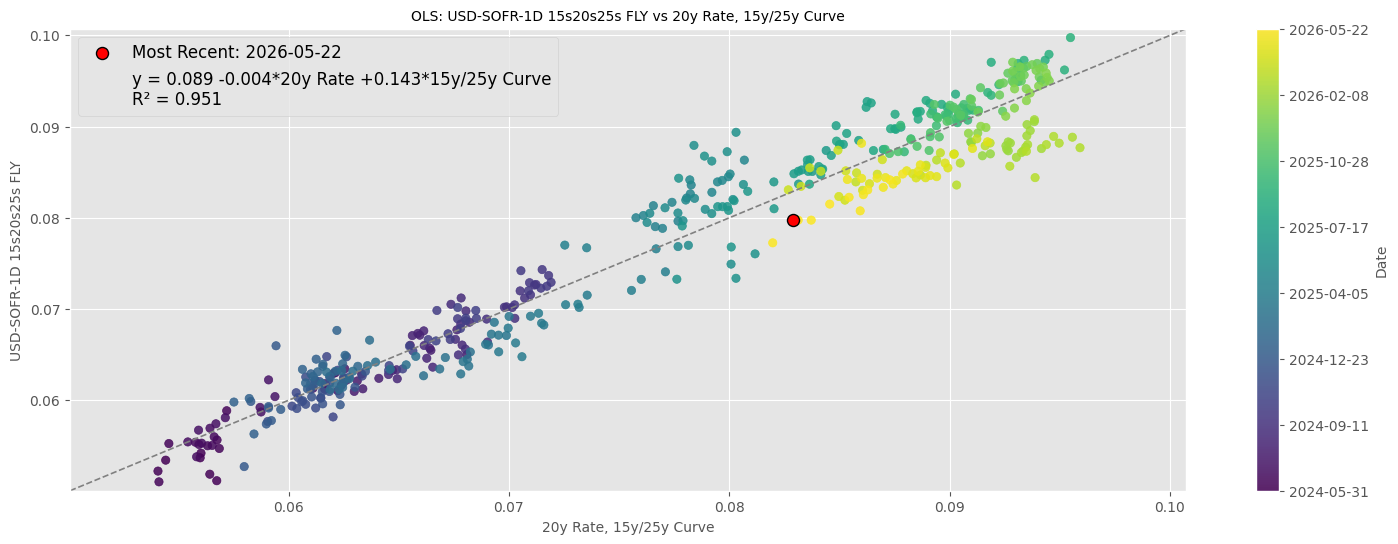

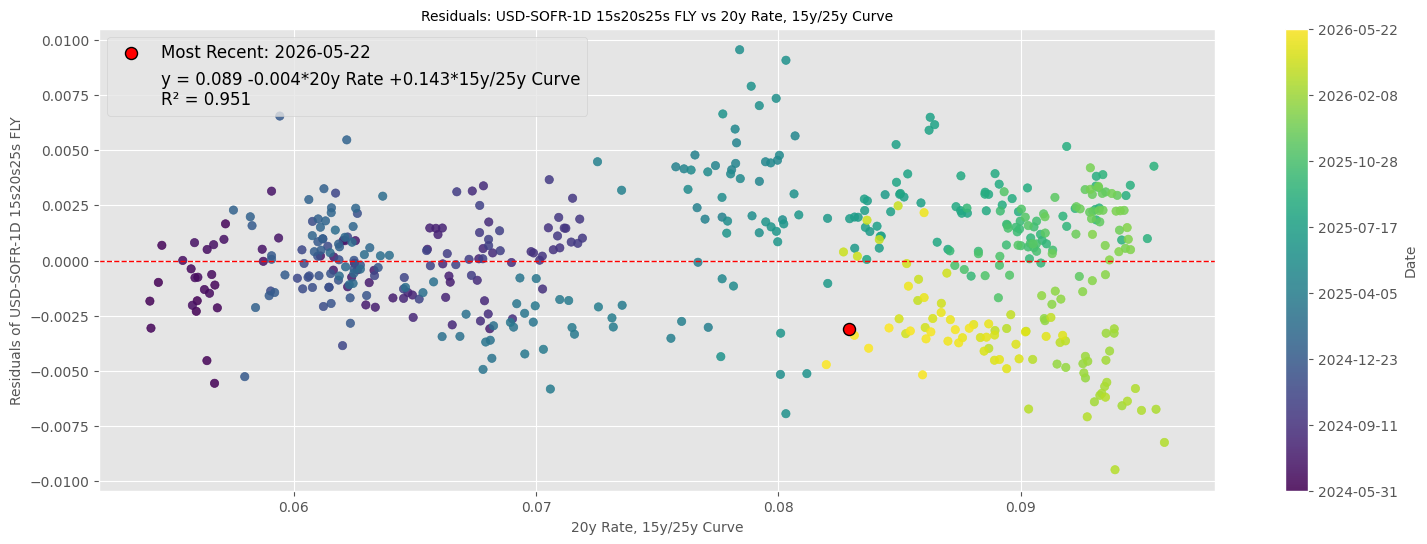

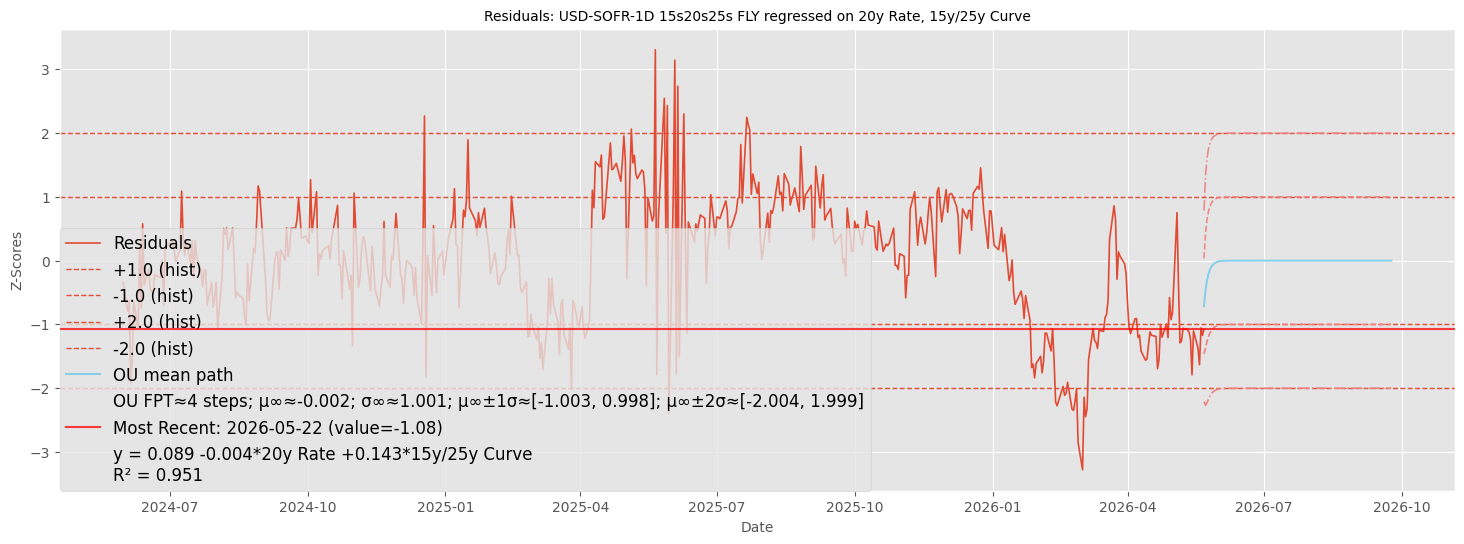

In [51]:
# --- Select a fly for detailed analysis (change index or set fly_name directly) ---
# selected_fly = display_df.iloc[0]["fly"]
selected_fly = "15s20s25s"

d = details[selected_fly]
row = summary[summary["fly"] == selected_fly].iloc[0]

print(f"{'='*60}")
print(f"{'='*60}")
print(f"  {SCREENER_CONFIG['curve']} {selected_fly} FLY — Detailed Regression Analysis")
print(f"  Direction:    {row['direction']}")
print(f"  Fly level:    {row['fly_bps']:.1f} bps")
print(f"  Predicted:    {row['predicted_bps']:.1f} bps")
print(f"  Residual:     {row['residual_bps']:.2f} bps")
print(f"  β(belly):     {row['β_belly']:.4f}   β(curve):  {row['β_curve']:.4f}   R²: {row['R²']:.3f}")
print(f"  Weights:      short={row['w_short']:.3f}  belly={row['w_belly']:.3f}  long={row['w_long']:.3f}")
print(f"  Z-scores:     " + "  ".join(f"{w}d={row[f'z_{w}d']:.2f}" for w in SCREENER_CONFIG["zscore_windows"]))
print(f"  Fly C&R:      {row['fly_cr_ann']:.1f} bps/yr    Wtd C&R: {row['wtd_cr_ann']:.1f} bps/yr")
print(f"  Resid Vol:    {row['resid_vol']:.1f} bps/yr    Risk-Adj: {row['dir_risk_adj']:.2f}")
print(f"  Half-life:    {row['half_life']:.1f} days      ADF p: {row['adf_p']:.3f}   Hurst: {row['hurst']:.2f}")
print(f"{'='*60}")

# --- Full regression using make_linear_regression_builder ---
add_x, fit_fn, plot_avp, plot_rvp, plot_rts, get_data = make_linear_regression_builder(
    y=d["fly"],
    date_color_bar=True,
)
add_x(d["belly"], name=f"{row['belly']} Rate")
add_x(d["curve"], name=f"{row['short']}/{row['long']} Curve")

res_detail = fit_fn(model=SCREENER_CONFIG["regression_model"], verbose=True)
plot_avp()
plot_rvp()
plot_rts(plot_zscores=True, stds=[1, 2], ou_bands=True)

In [52]:
rv_indicators = [
    # {"kind": "sma", "window": 21, "style": {"linestyle": "--", "linewidth": 1}},
    # {"kind": "sma", "window": 63, "style": {"linestyle": "-.", "linewidth": 1}},
    # {"kind": "boll", "window": 63, "n": 2, "center": False},
    # {"kind": "z", "window": 63, "hide": True, "label": "Z(63d)"},
    # {"kind": "z", "window": 126, "hide": True, "label": "Z(126d)"},
    # {"kind": "z", "window": 252, "hide": True, "label": "Z(252d)"},
    # {"kind": "half_life", "method": "ou", "hide": True, "label": "OU Half-Life (days)"},
    # {"kind": "hurst", "hide": True, "label": "Hurst Exponent"},
    # {"kind": "adf_p", "hide": True, "label": "ADF p-value"},
    # {"kind": "vol", "window": 63, "returns": "normal", "hide": True, "label": "Vol(63d) bps/yr"},
    # {"kind": "cum_change", "n": 1, "hide": True, "label": "Δ1d"},
    # {"kind": "cum_change", "n": 5, "hide": True, "label": "Δ1w"},
    # {"kind": "cum_change", "n": 21, "hide": True, "label": "Δ1m"},
    # {"kind": "cum_change", "n": 63, "hide": True, "label": "Δ3m"},
]

# --- Equal-Weighted Fly ---
plot_fn, fig1, _, _, legend_fn = make_secondary_axis_plot(
    engine="plotly", title=f"{SCREENER_CONFIG['curve']} {selected_fly} Equal-Weighted Fly"
)
plot_fn(d["fly"], label="Equal-Wt Fly", indicators=rv_indicators, ou={"enable": True, "steps": 126})
legend_fn(show_date=True, valfmt="{:.4f}")

# --- Beta-Weighted Fly (Residual) ---
plot_fn2, fig2, _, _, legend_fn2 = make_secondary_axis_plot(
    engine="plotly", title=f"{SCREENER_CONFIG['curve']} {selected_fly} Beta-Weighted Fly (Residual)"
)
plot_fn2(d["resid"], label="Beta-Wt Fly (Resid)", indicators=rv_indicators, ou={"enable": True, "steps": 126})
legend_fn2(show_date=True, valfmt="{:.4f}")